# 03 - Exploratory Data Analysis

# Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# plot settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# output directory
os.makedirs('../reports/figures/eda', exist_ok=True)
os.makedirs('../reports/tables', exist_ok=True)

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
print('shape:', df.shape)
df.head()

shape: (88167, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,"acoustic, j-pop, singer-songwriter, songwriter"
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,"acoustic, chill"
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Section 1 - Distribution of Numeric Features

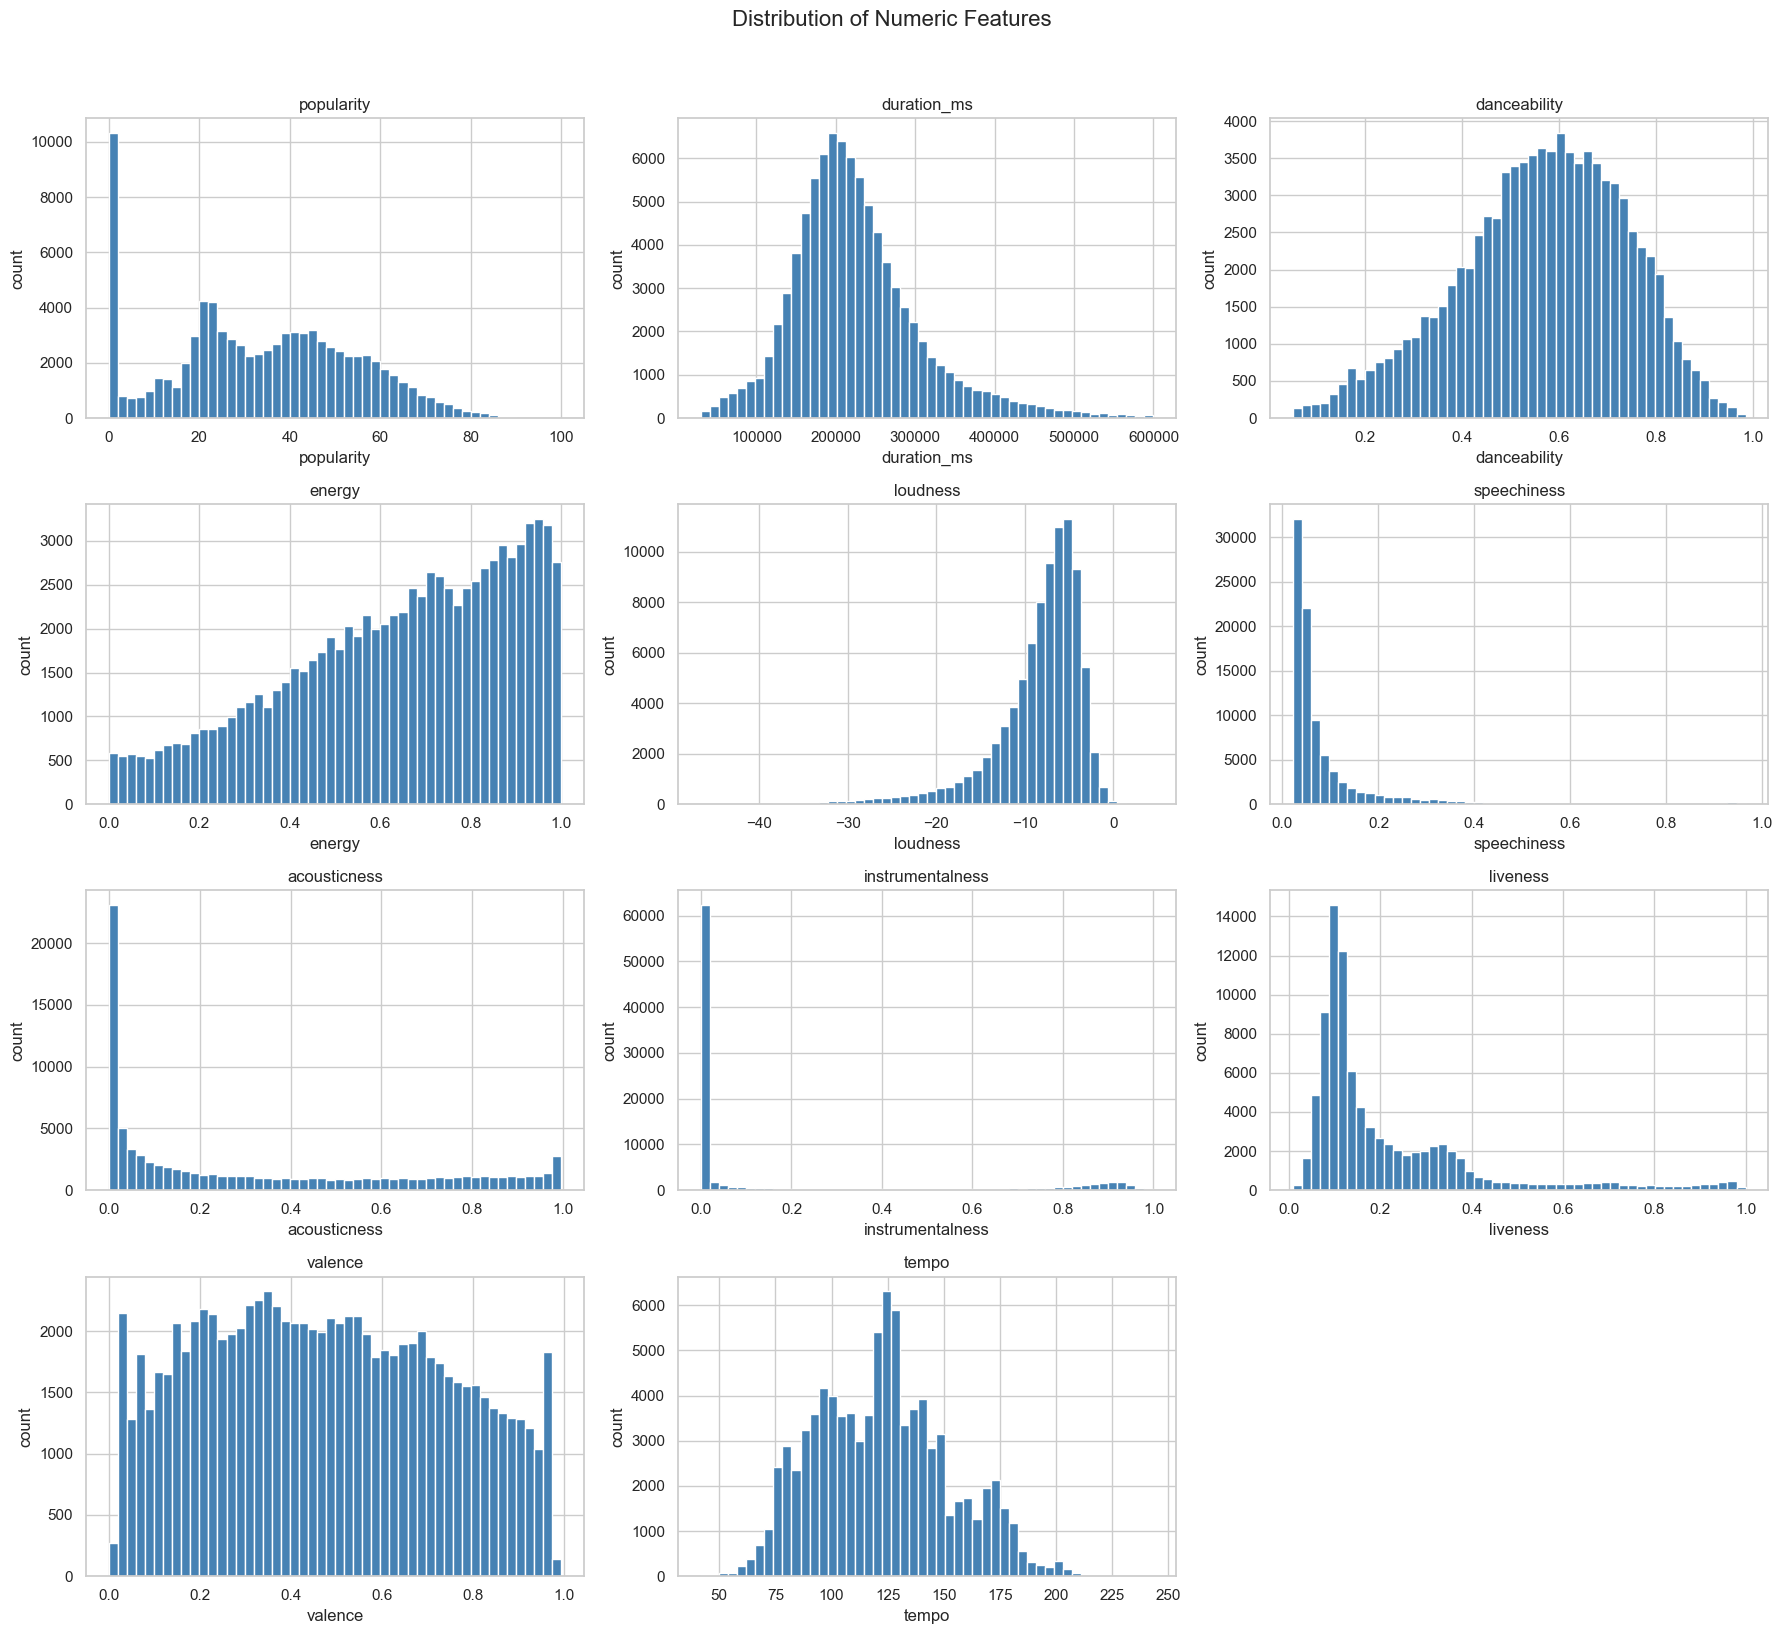

In [2]:
numeric_cols = ['popularity', 'duration_ms', 'danceability', 'energy', 
                'loudness', 'speechiness', 'acousticness', 
                'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

axes[-1].set_visible(False)

plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/eda/numeric_distributions.png', bbox_inches='tight')
plt.show()

# Section 2 - Box Plots for Numeric Features

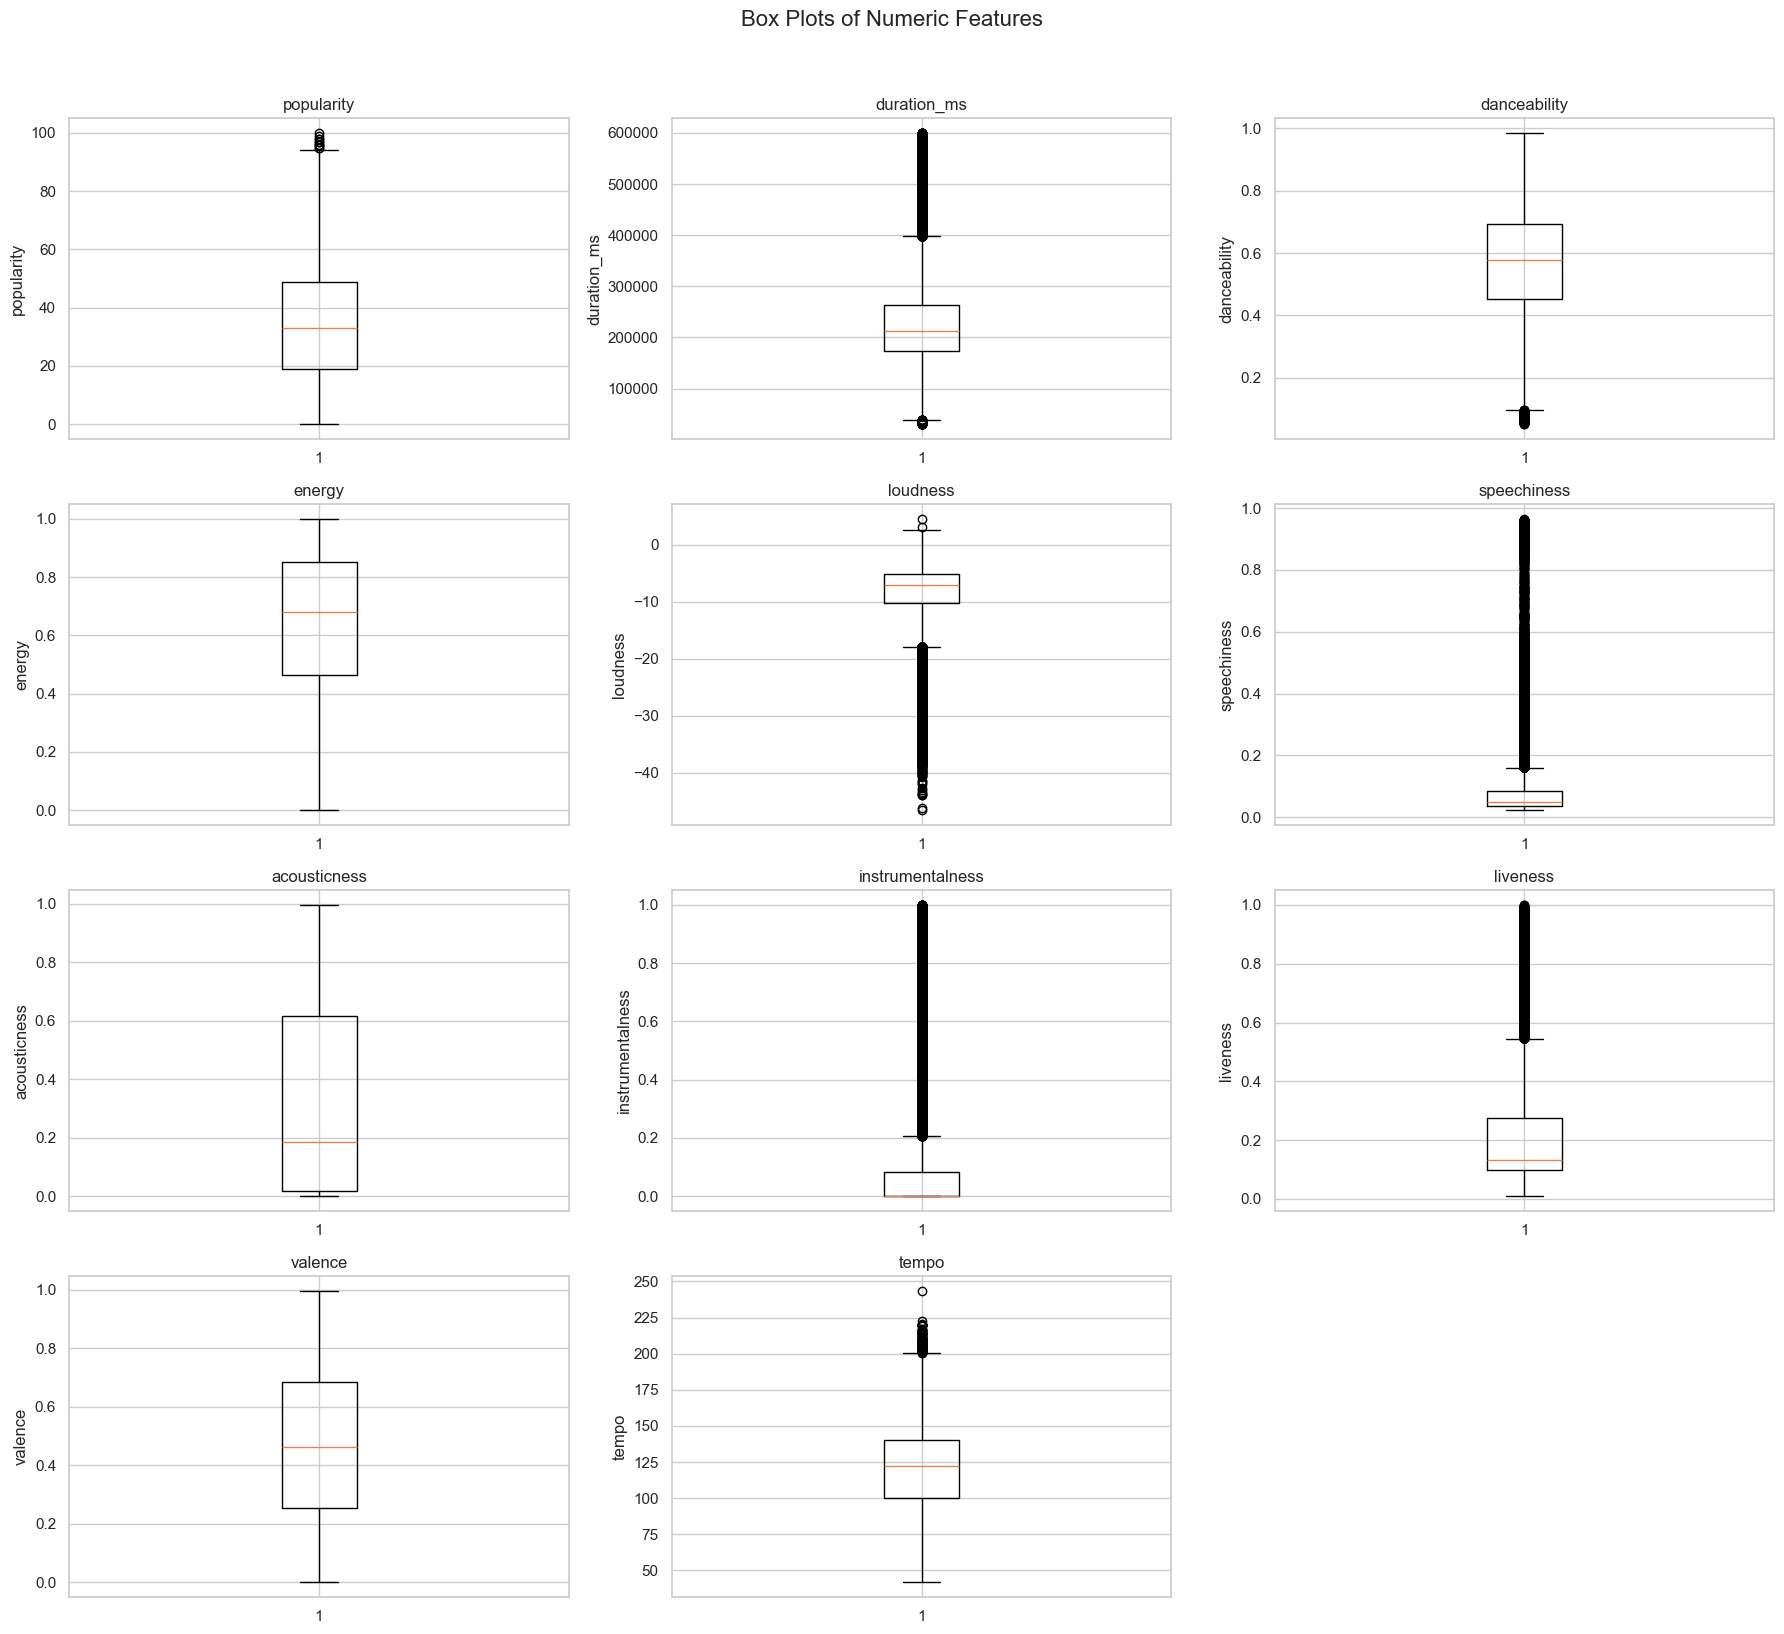

In [3]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)

plt.suptitle('Box Plots of Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/eda/boxplots_numeric.png', bbox_inches='tight')
plt.show()

# Section 3 - Categorical Feature Analysis

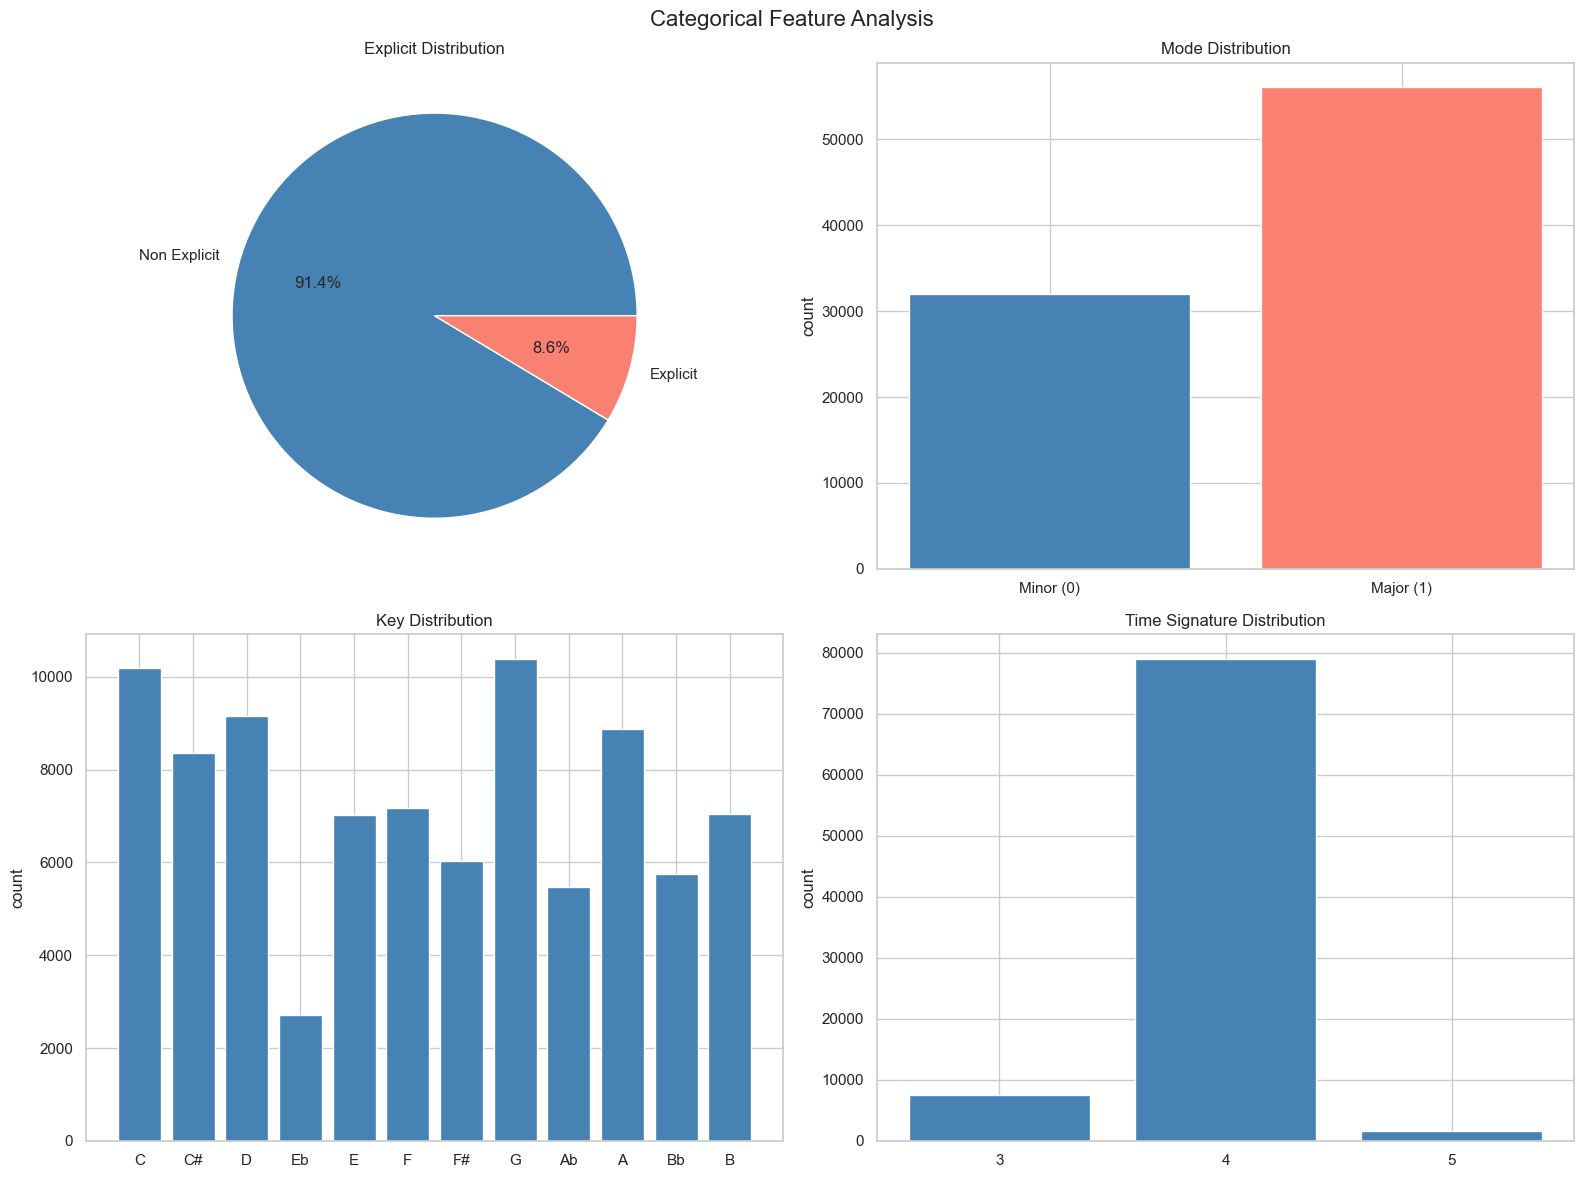

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# explicit
explicit_counts = df['explicit'].value_counts()
axes[0, 0].pie(explicit_counts, labels=['Non Explicit', 'Explicit'], autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[0, 0].set_title('Explicit Distribution')

# mode
mode_counts = df['mode'].value_counts().sort_index()
axes[0, 1].bar(['Minor (0)', 'Major (1)'], mode_counts.values, color=['steelblue', 'salmon'])
axes[0, 1].set_title('Mode Distribution')
axes[0, 1].set_ylabel('count')

# key
key_labels = ['C', 'C#', 'D', 'Eb', 'E', 'F', 'F#', 'G', 'Ab', 'A', 'Bb', 'B']
key_counts = df['key'].value_counts().sort_index()
axes[1, 0].bar(key_labels, key_counts.values, color='steelblue')
axes[1, 0].set_title('Key Distribution')
axes[1, 0].set_ylabel('count')

# time signature
ts_counts = df['time_signature'].value_counts().sort_index()
axes[1, 1].bar(ts_counts.index.astype(str), ts_counts.values, color='steelblue')
axes[1, 1].set_title('Time Signature Distribution')
axes[1, 1].set_ylabel('count')

plt.suptitle('Categorical Feature Analysis', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/eda/categorical_analysis.png', bbox_inches='tight')
plt.show()

# Section 4 - Correlation Analysis

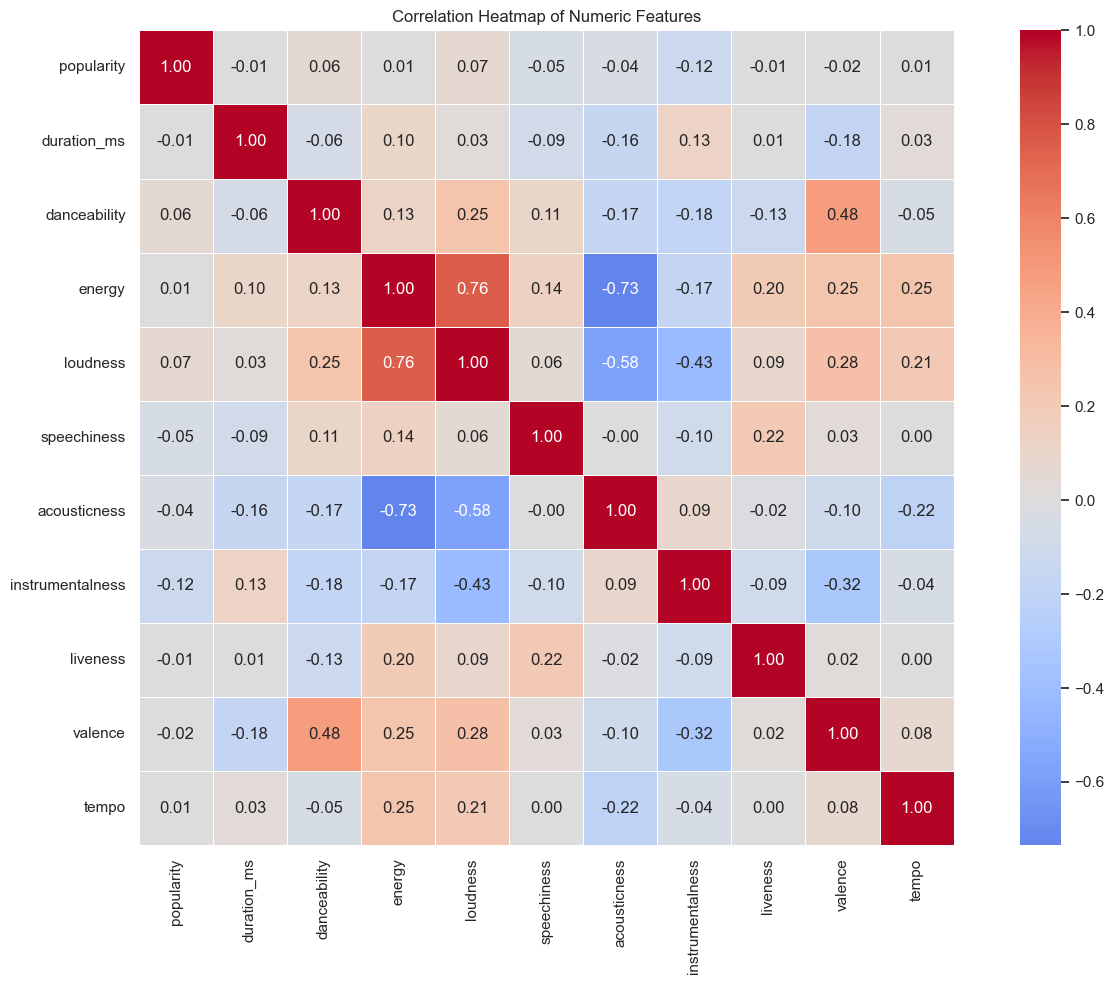

In [5]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('../reports/figures/eda/correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [7]:
# top correlations to table:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs = corr_pairs.drop_duplicates()
corr_pairs = corr_pairs.abs().sort_values(ascending=False)

top_corr = corr_pairs.head(10).reset_index()
top_corr.columns = ['feature_1', 'feature_2', 'correlation']
top_corr.to_csv('../reports/tables/top_correlations.csv', index=False)
print(top_corr)

          feature_1         feature_2  correlation
0            energy          loudness     0.759414
1            energy      acousticness     0.734566
2          loudness      acousticness     0.582908
3      danceability           valence     0.482420
4          loudness  instrumentalness     0.428100
5  instrumentalness           valence     0.322797
6          loudness           valence     0.276265
7      danceability          loudness     0.250916
8            energy           valence     0.247736
9            energy             tempo     0.246015


# Section 5 - Popularity Analysis

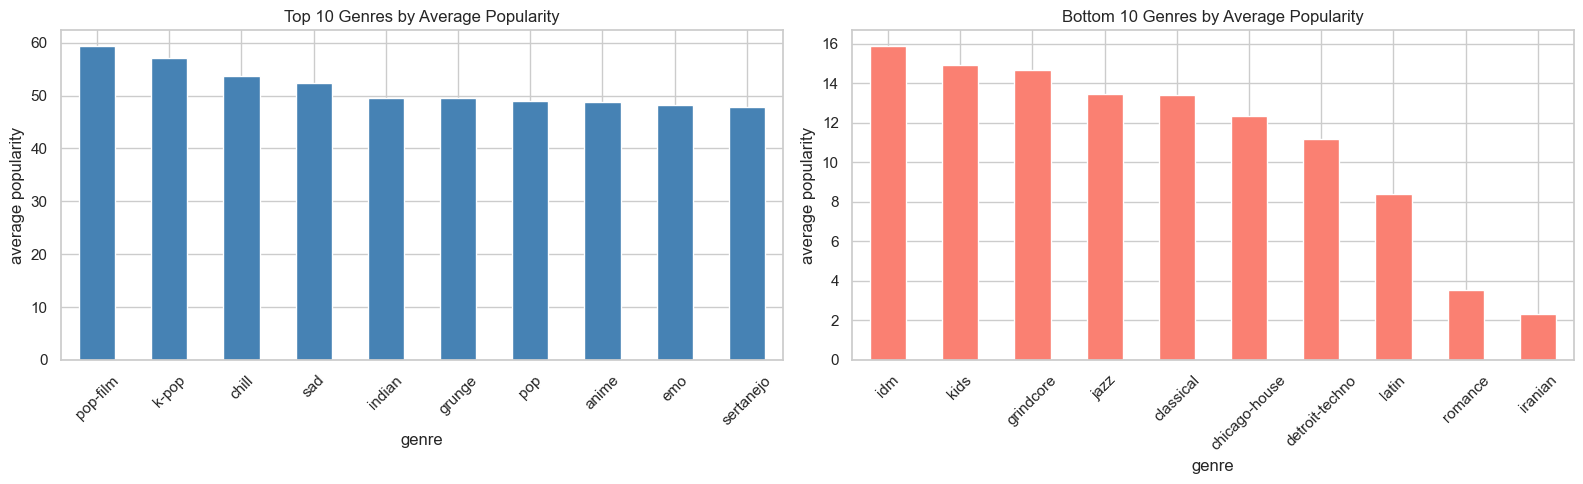

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# popularity by genre top 10
genre_popularity = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

# since genres are merged now, split and explode first
df_exploded = df.copy()
df_exploded['track_genre'] = df_exploded['track_genre'].str.split(', ')
df_exploded = df_exploded.explode('track_genre')

genre_pop = df_exploded.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

genre_pop.head(10).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Genres by Average Popularity')
axes[0].set_xlabel('genre')
axes[0].set_ylabel('average popularity')
axes[0].tick_params(axis='x', rotation=45)

genre_pop.tail(10).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Bottom 10 Genres by Average Popularity')
axes[1].set_xlabel('genre')
axes[1].set_ylabel('average popularity')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/eda/popularity_by_genre.png', bbox_inches='tight')
plt.show()

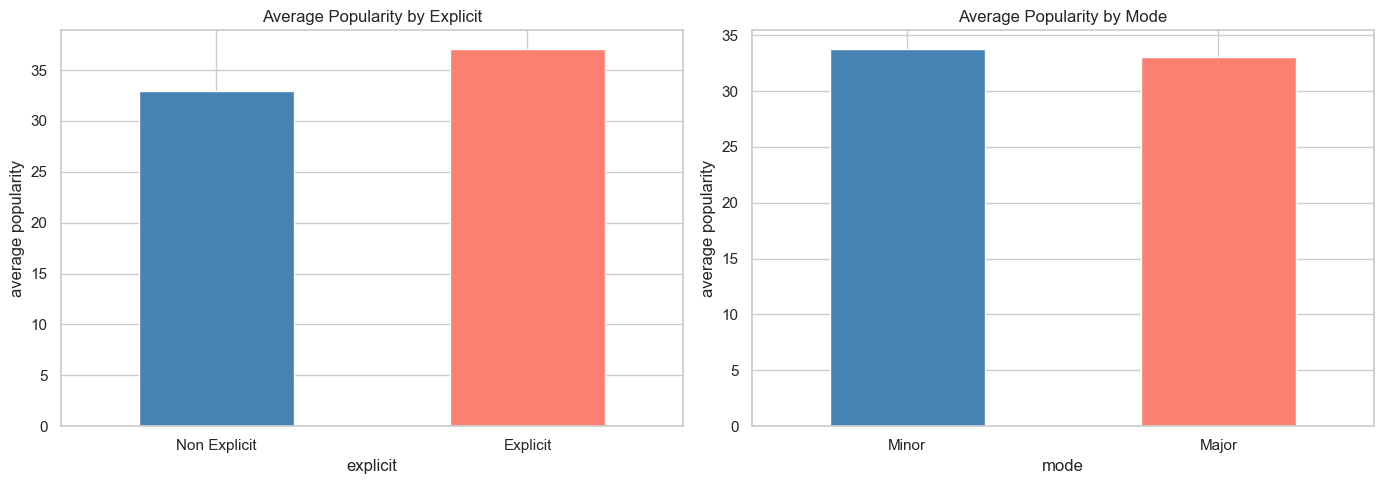

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# popularity by explicit
df.groupby('explicit')['popularity'].mean().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Average Popularity by Explicit')
axes[0].set_xlabel('explicit')
axes[0].set_ylabel('average popularity')
axes[0].set_xticklabels(['Non Explicit', 'Explicit'], rotation=0)

# popularity by mode
df.groupby('mode')['popularity'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Average Popularity by Mode')
axes[1].set_xlabel('mode')
axes[1].set_ylabel('average popularity')
axes[1].set_xticklabels(['Minor', 'Major'], rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/eda/popularity_by_explicit_mode.png', bbox_inches='tight')
plt.show()

# Popularity vs Audio Features

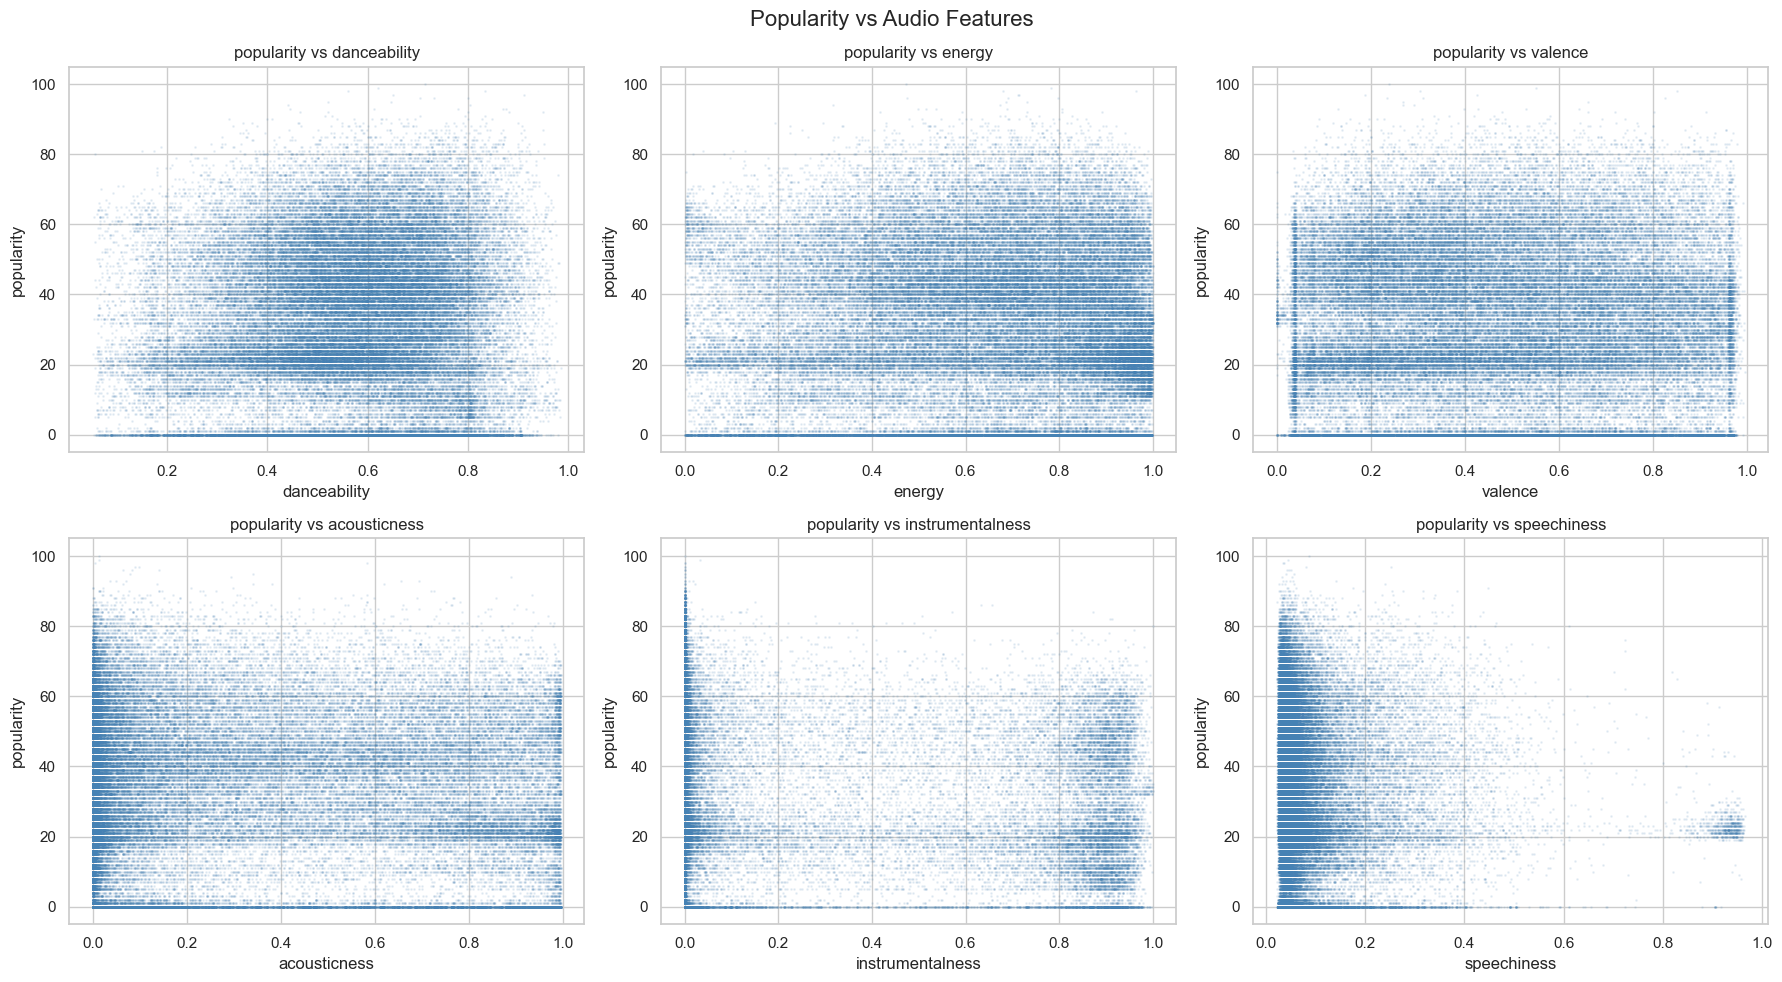

In [10]:
features = ['danceability', 'energy', 'valence', 'acousticness', 
            'instrumentalness', 'speechiness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['popularity'], alpha=0.1, color='steelblue', s=1)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('popularity')
    axes[i].set_title(f'popularity vs {feature}')

plt.suptitle('Popularity vs Audio Features', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/eda/popularity_vs_features.png', bbox_inches='tight')
plt.show()

# Key vs Popularity

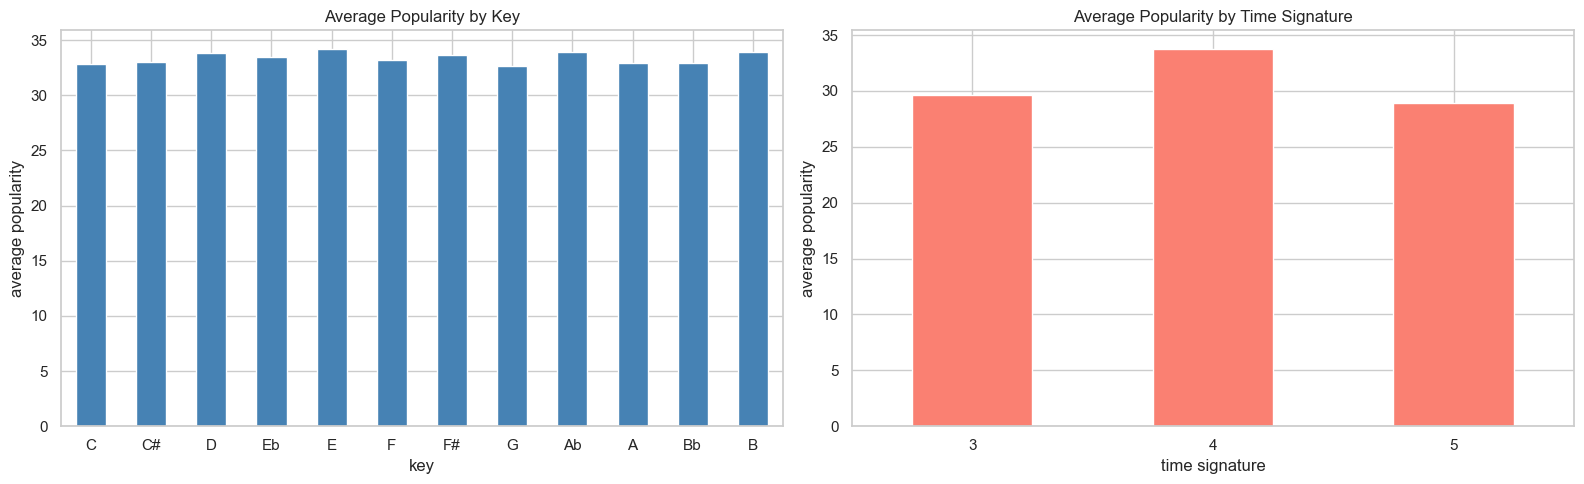

In [24]:
key_labels = {0:'C', 1:'C#', 2:'D', 3:'Eb', 4:'E', 5:'F', 
              6:'F#', 7:'G', 8:'Ab', 9:'A', 10:'Bb', 11:'B'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['key_name'] = df['key'].map(key_labels)
key_pop = df.groupby('key_name')['popularity'].mean().reindex(key_labels.values())

key_pop.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Popularity by Key')
axes[0].set_xlabel('key')
axes[0].set_ylabel('average popularity')
axes[0].tick_params(axis='x', rotation=0)

# time signature vs popularity
df.groupby('time_signature')['popularity'].mean().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Average Popularity by Time Signature')
axes[1].set_xlabel('time signature')
axes[1].set_ylabel('average popularity')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/eda/key_timesig_popularity.png', bbox_inches='tight')
plt.show()

df.drop(columns=['key_name'], inplace=True)

# Top 20 Most Popular Songs

In [11]:
top_20 = df.nlargest(20, 'popularity')[['track_name', 'artists', 'popularity', 'track_genre']]
top_20 = top_20.reset_index(drop=True)
top_20.index += 1
print(top_20.to_string())

top_20.to_csv('../reports/tables/top_20_popular_songs.csv', index=False)

                                 track_name                     artists  popularity                       track_genre
1                 Unholy (feat. Kim Petras)        Sam Smith;Kim Petras         100                        dance, pop
2     Quevedo: Bzrp Music Sessions, Vol. 52            Bizarrap;Quevedo          99                           hip-hop
3                           I'm Good (Blue)     David Guetta;Bebe Rexha          98                   dance, edm, pop
4                                La Bachata               Manuel Turizo          98  latin, latino, reggae, reggaeton
5                           Me Porto Bonito  Bad Bunny;Chencho Corleone          97  latin, latino, reggae, reggaeton
6                          Tití Me Preguntó                   Bad Bunny          97  latin, latino, reggae, reggaeton
7                       Under The Influence                 Chris Brown          96                        dance, pop
8                                    Efecto             

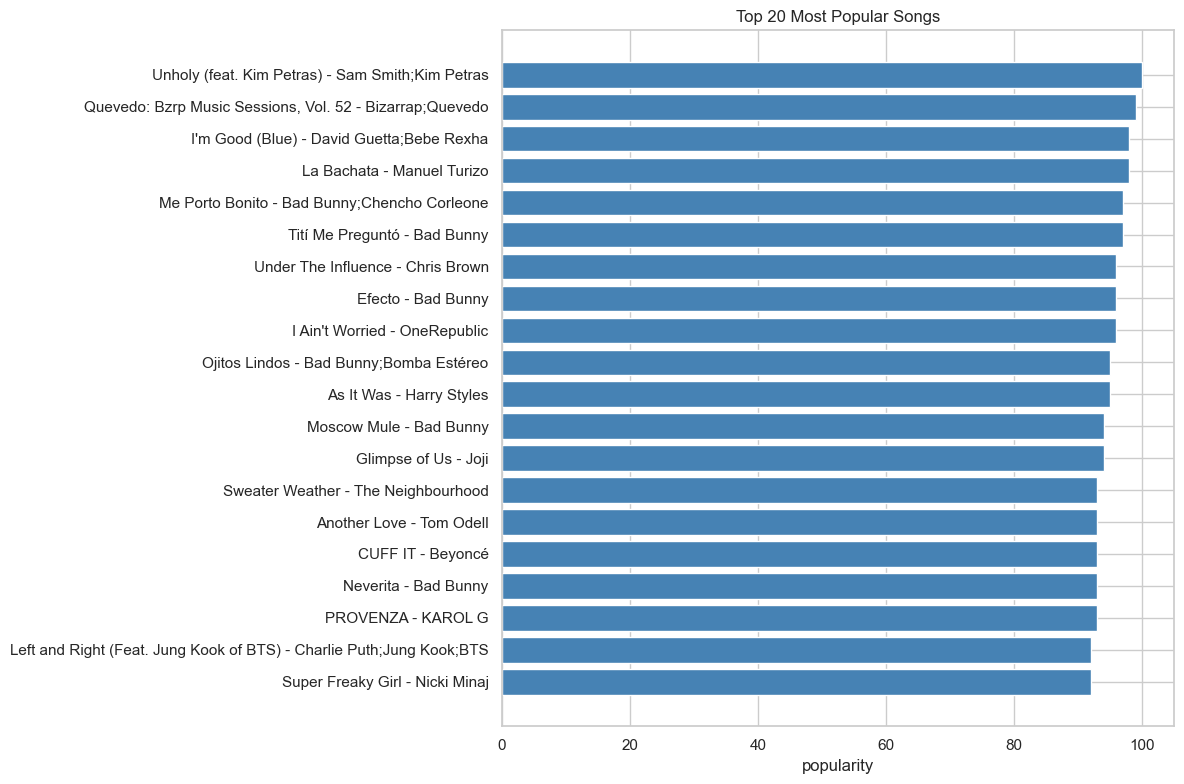

In [12]:
plt.figure(figsize=(12, 8))
plt.barh(top_20['track_name'] + ' - ' + top_20['artists'], 
         top_20['popularity'], color='steelblue')
plt.xlabel('popularity')
plt.title('Top 20 Most Popular Songs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/eda/top_20_popular_songs.png', bbox_inches='tight')
plt.show()

# Section 6 - Average Audio Features per Genre

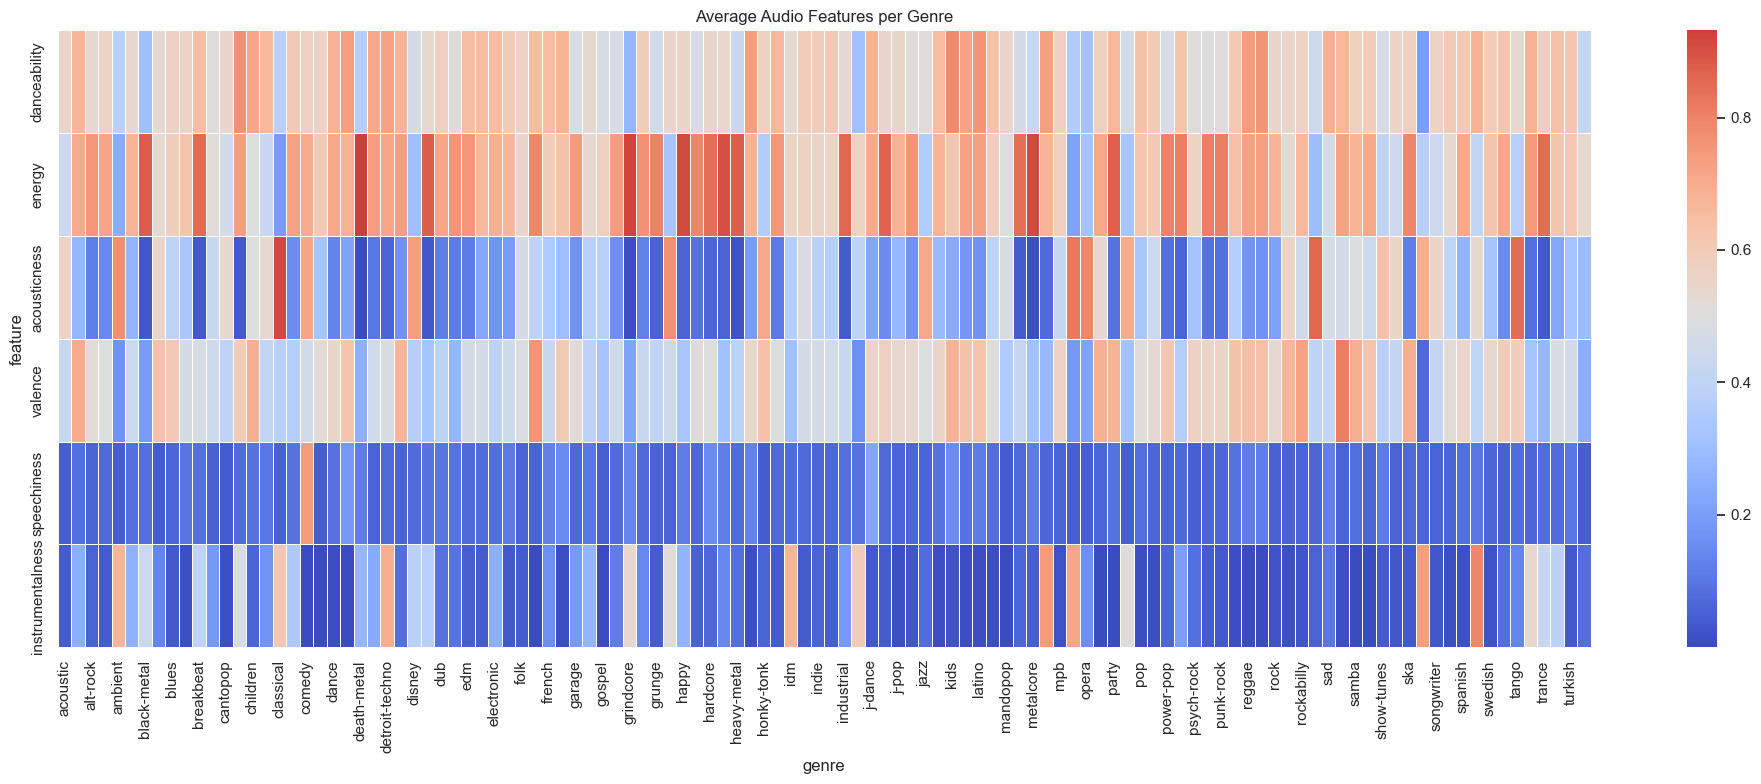

In [13]:
audio_features = ['danceability', 'energy', 'acousticness', 
                  'valence', 'speechiness', 'instrumentalness']

genre_features = df_exploded.groupby('track_genre')[audio_features].mean()

plt.figure(figsize=(20, 8))
sns.heatmap(genre_features.T, cmap='coolwarm', center=0.5, 
            linewidths=0.5, yticklabels=True)
plt.title('Average Audio Features per Genre')
plt.xlabel('genre')
plt.ylabel('feature')
plt.tight_layout()
plt.savefig('../reports/figures/eda/genre_audio_features_heatmap.png', bbox_inches='tight')
plt.show()

# Genre Overlap Analysis

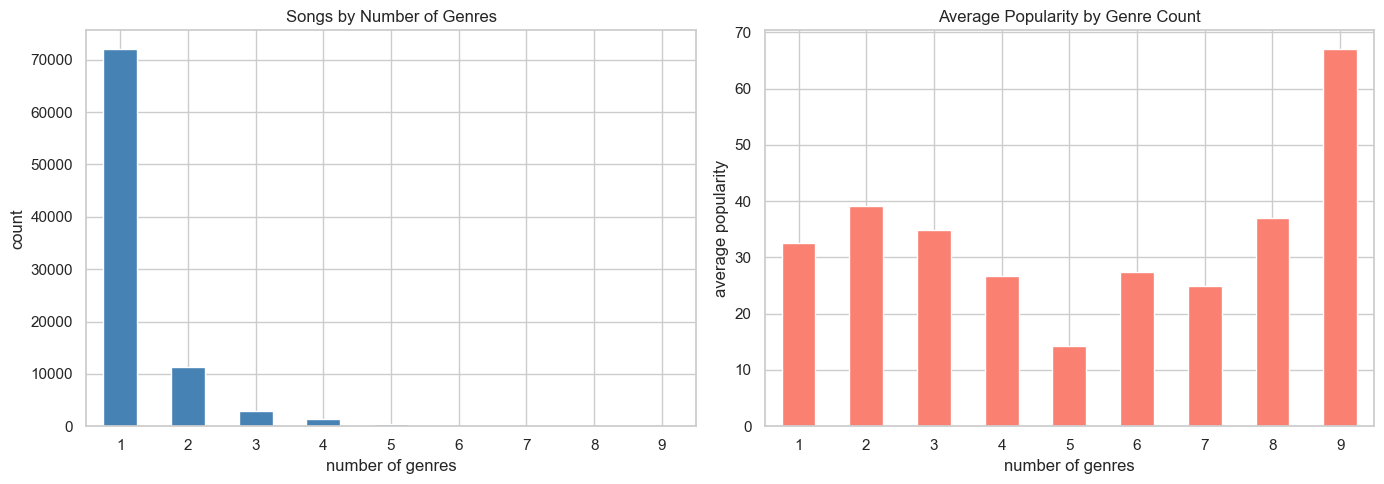

In [14]:
genre_count = df['track_genre'].str.split(', ').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution
genre_count.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Songs by Number of Genres')
axes[0].set_xlabel('number of genres')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=0)

# popularity by genre count
df['genre_count'] = genre_count
df.groupby('genre_count')['popularity'].mean().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Average Popularity by Genre Count')
axes[1].set_xlabel('number of genres')
axes[1].set_ylabel('average popularity')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/eda/genre_overlap_analysis.png', bbox_inches='tight')
plt.show()

df.drop(columns=['genre_count'], inplace=True)

# Most Common Genre Combinations

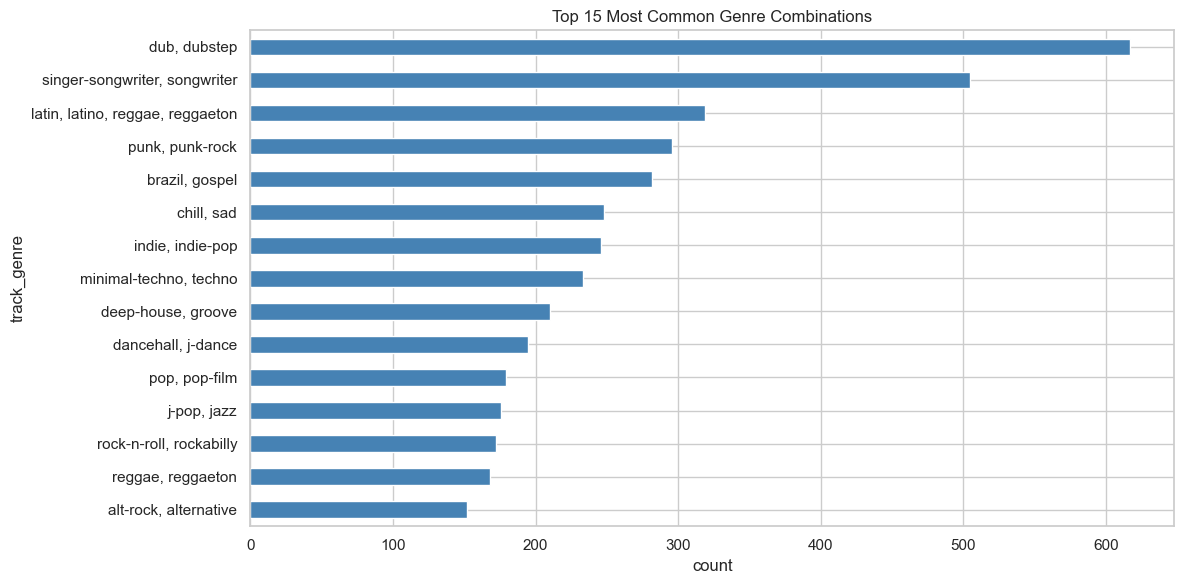

track_genre
dub, dubstep                        617
singer-songwriter, songwriter       505
latin, latino, reggae, reggaeton    319
punk, punk-rock                     296
brazil, gospel                      282
chill, sad                          248
indie, indie-pop                    246
minimal-techno, techno              233
deep-house, groove                  210
dancehall, j-dance                  195
pop, pop-film                       179
j-pop, jazz                         176
rock-n-roll, rockabilly             172
reggae, reggaeton                   168
alt-rock, alternative               152
Name: count, dtype: int64


In [15]:
multi_genre = df[df['track_genre'].str.contains(',')]
top_combinations = multi_genre['track_genre'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_combinations.plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Common Genre Combinations')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/eda/top_genre_combinations.png', bbox_inches='tight')
plt.show()

print(top_combinations)

# Genre Audio Fingerprint (Radar Chart)

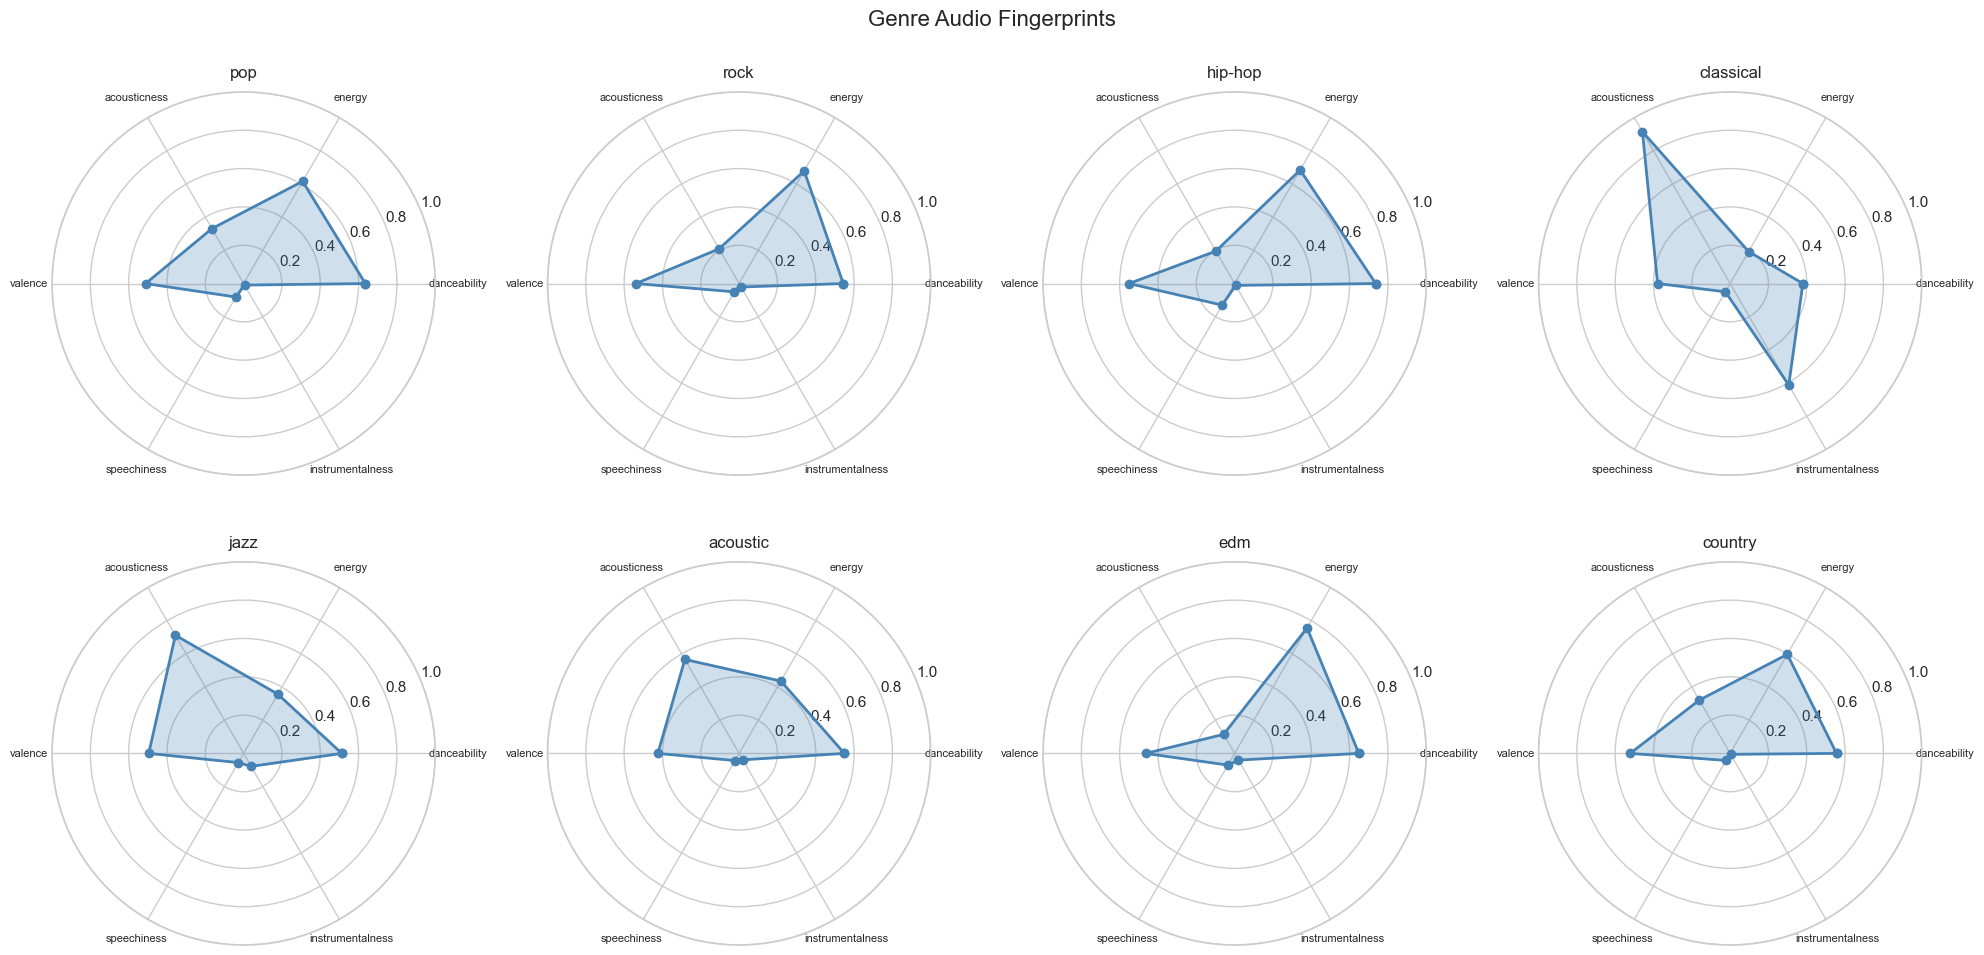

In [25]:
from matplotlib.patches import FancyArrowPatch
import numpy as np

genres_to_plot = ['pop', 'rock', 'hip-hop', 'classical', 'jazz', 'acoustic', 'edm', 'country']
features = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']

genre_avg = df_exploded[df_exploded['track_genre'].isin(genres_to_plot)].groupby('track_genre')[features].mean()

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, genre in enumerate(genres_to_plot):
    values = genre_avg.loc[genre].tolist()
    values += values[:1]
    axes[i].plot(angles, values, 'o-', linewidth=2, color='steelblue')
    axes[i].fill(angles, values, alpha=0.25, color='steelblue')
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(features, size=8)
    axes[i].set_title(genre, size=12, pad=10)
    axes[i].set_ylim(0, 1)

plt.suptitle('Genre Audio Fingerprints', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/eda/genre_radar_charts.png', bbox_inches='tight')
plt.show()

# Section 7 - Mood Analysis

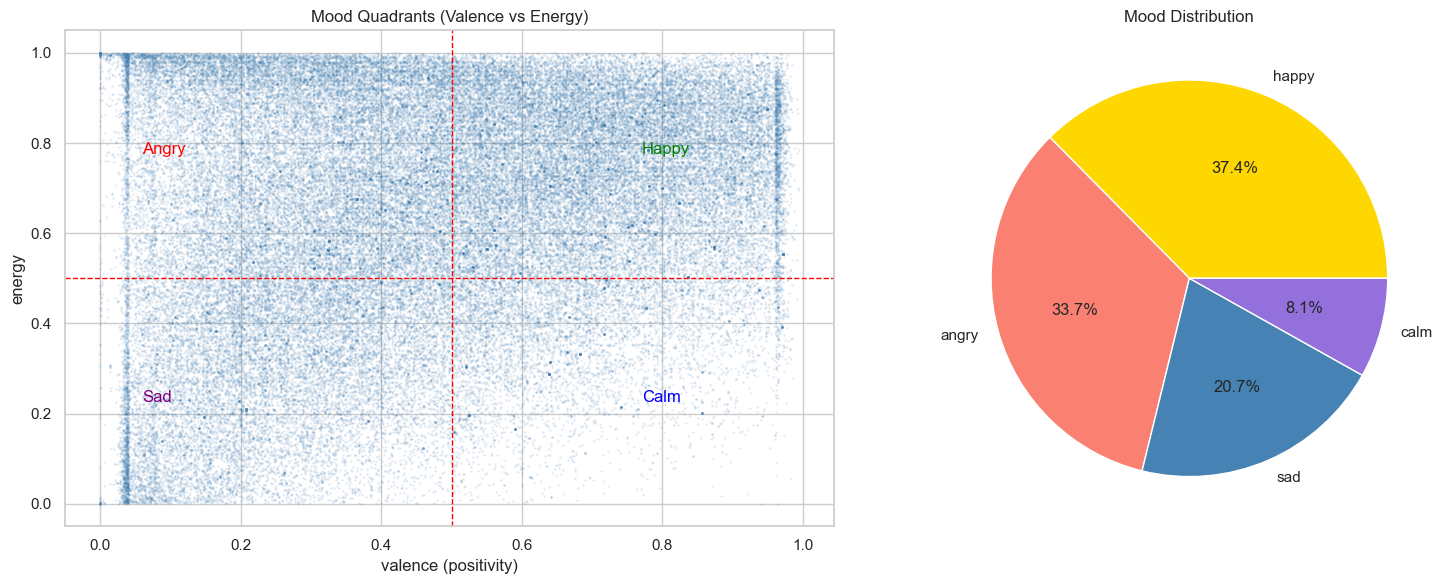

mood
happy    32992
angry    29754
sad      18252
calm      7169
Name: count, dtype: int64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# valence vs energy scatter (mood quadrants)
axes[0].scatter(df['valence'], df['energy'], alpha=0.1, s=1, color='steelblue')
axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=1)
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('valence (positivity)')
axes[0].set_ylabel('energy')
axes[0].set_title('Mood Quadrants (Valence vs Energy)')
axes[0].text(0.75, 0.75, 'Happy', transform=axes[0].transAxes, fontsize=12, color='green')
axes[0].text(0.1, 0.75, 'Angry', transform=axes[0].transAxes, fontsize=12, color='red')
axes[0].text(0.75, 0.25, 'Calm', transform=axes[0].transAxes, fontsize=12, color='blue')
axes[0].text(0.1, 0.25, 'Sad', transform=axes[0].transAxes, fontsize=12, color='purple')

# mood distribution
df['mood'] = 'sad'
df.loc[(df['valence'] >= 0.5) & (df['energy'] >= 0.5), 'mood'] = 'happy'
df.loc[(df['valence'] < 0.5) & (df['energy'] >= 0.5), 'mood'] = 'angry'
df.loc[(df['valence'] >= 0.5) & (df['energy'] < 0.5), 'mood'] = 'calm'

mood_counts = df['mood'].value_counts()
axes[1].pie(mood_counts, labels=mood_counts.index, autopct='%1.1f%%',
            colors=['gold', 'salmon', 'steelblue', 'mediumpurple'])
axes[1].set_title('Mood Distribution')

plt.tight_layout()
plt.savefig('../reports/figures/eda/mood_analysis.png', bbox_inches='tight')
plt.show()

print(mood_counts)
df.drop(columns=['mood'], inplace=True)

# Section 8 - Artist Analysis

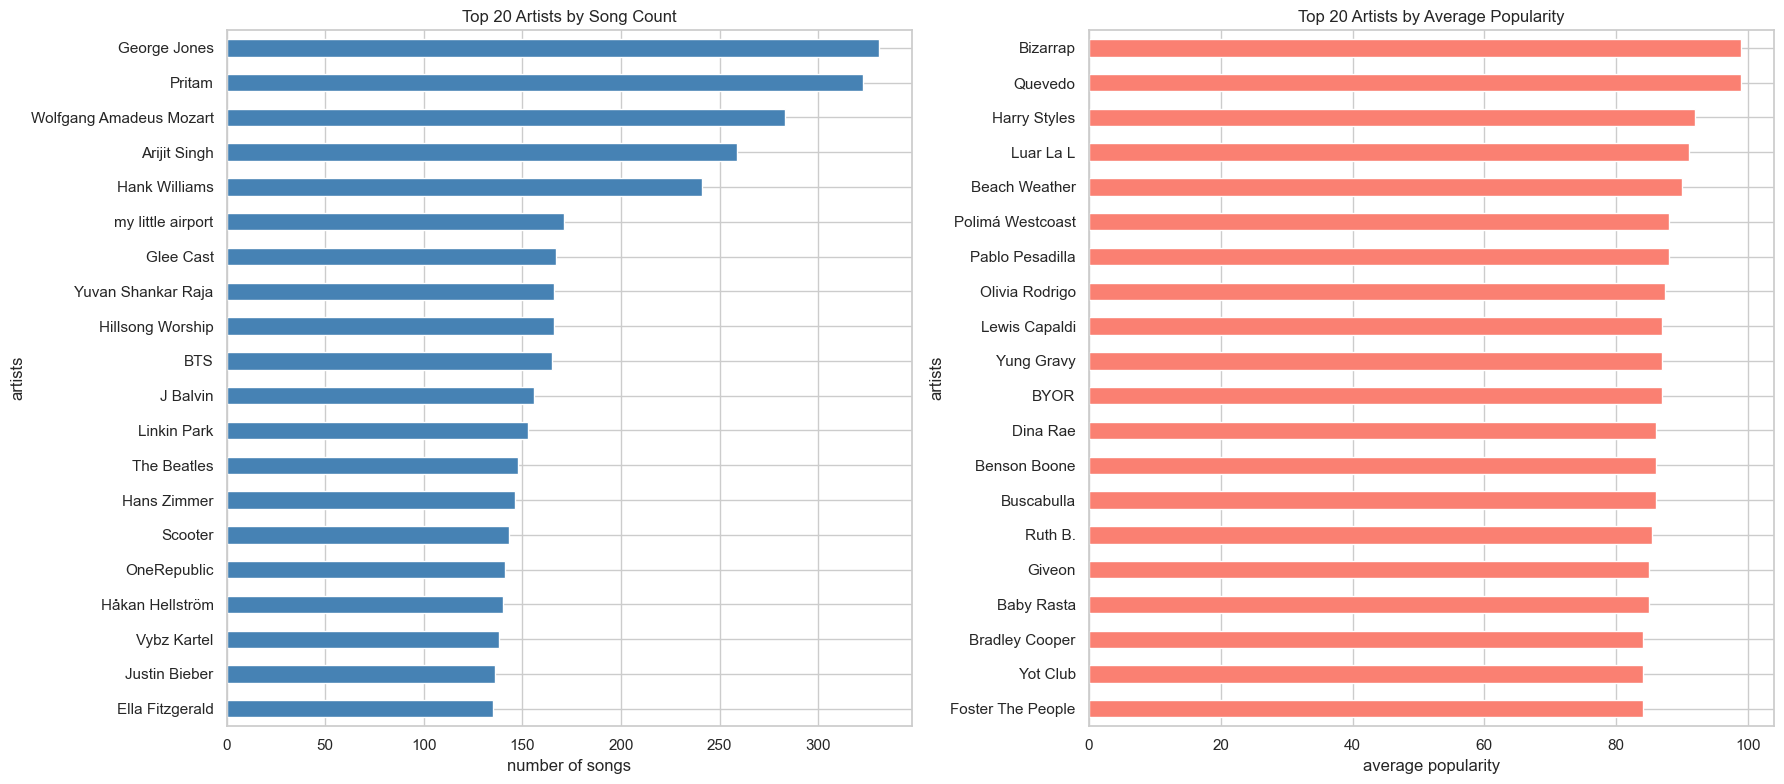

In [17]:
df_artists = df.copy()
df_artists['artists'] = df_artists['artists'].str.split(';')
df_artists = df_artists.explode('artists')
df_artists['artists'] = df_artists['artists'].str.strip()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# top 20 by song count
top_artists_count = df_artists['artists'].value_counts().head(20)
top_artists_count.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Artists by Song Count')
axes[0].set_xlabel('number of songs')
axes[0].invert_yaxis()

# top 20 by average popularity
top_artists_pop = df_artists.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(20)
top_artists_pop.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 20 Artists by Average Popularity')
axes[1].set_xlabel('average popularity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/eda/artist_analysis.png', bbox_inches='tight')
plt.show()

# Section 9 - Duration Analysis

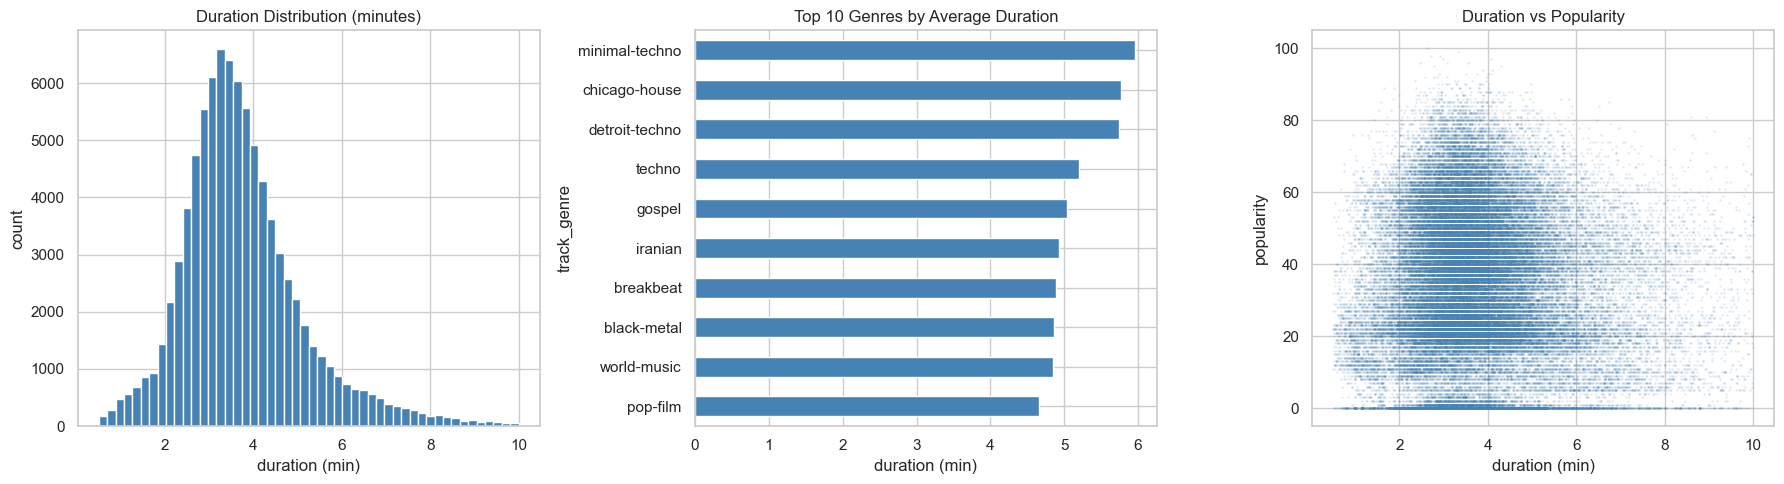

In [18]:
df['duration_min'] = df['duration_ms'] / 60000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# duration distribution
axes[0].hist(df['duration_min'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Duration Distribution (minutes)')
axes[0].set_xlabel('duration (min)')
axes[0].set_ylabel('count')

# duration by genre top 10
dur_by_genre = df_exploded.groupby('track_genre')['duration_ms'].mean().sort_values(ascending=False).head(10)
dur_by_genre = dur_by_genre / 60000
dur_by_genre.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Genres by Average Duration')
axes[1].set_xlabel('duration (min)')
axes[1].invert_yaxis()

# duration vs popularity
axes[2].scatter(df['duration_min'], df['popularity'], alpha=0.1, s=1, color='steelblue')
axes[2].set_title('Duration vs Popularity')
axes[2].set_xlabel('duration (min)')
axes[2].set_ylabel('popularity')

plt.tight_layout()
plt.savefig('../reports/figures/eda/duration_analysis.png', bbox_inches='tight')
plt.show()

df.drop(columns=['duration_min'], inplace=True)

# Section 10 - Tempo Analysis

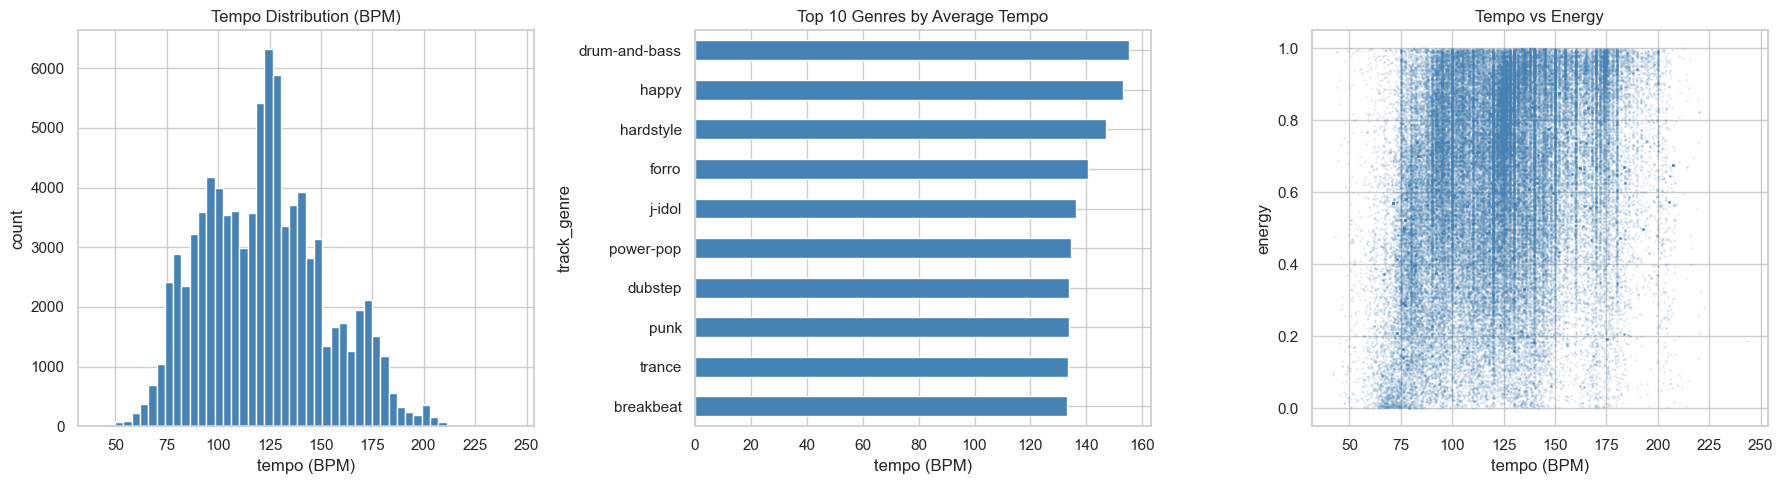

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# tempo distribution
axes[0].hist(df['tempo'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Tempo Distribution (BPM)')
axes[0].set_xlabel('tempo (BPM)')
axes[0].set_ylabel('count')

# tempo by genre top 10
tempo_by_genre = df_exploded.groupby('track_genre')['tempo'].mean().sort_values(ascending=False).head(10)
tempo_by_genre.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Genres by Average Tempo')
axes[1].set_xlabel('tempo (BPM)')
axes[1].invert_yaxis()

# tempo vs energy
axes[2].scatter(df['tempo'], df['energy'], alpha=0.1, s=1, color='steelblue')
axes[2].set_title('Tempo vs Energy')
axes[2].set_xlabel('tempo (BPM)')
axes[2].set_ylabel('energy')

plt.tight_layout()
plt.savefig('../reports/figures/eda/tempo_analysis.png', bbox_inches='tight')
plt.show()

# Section 11 - Explicit Content Analysis

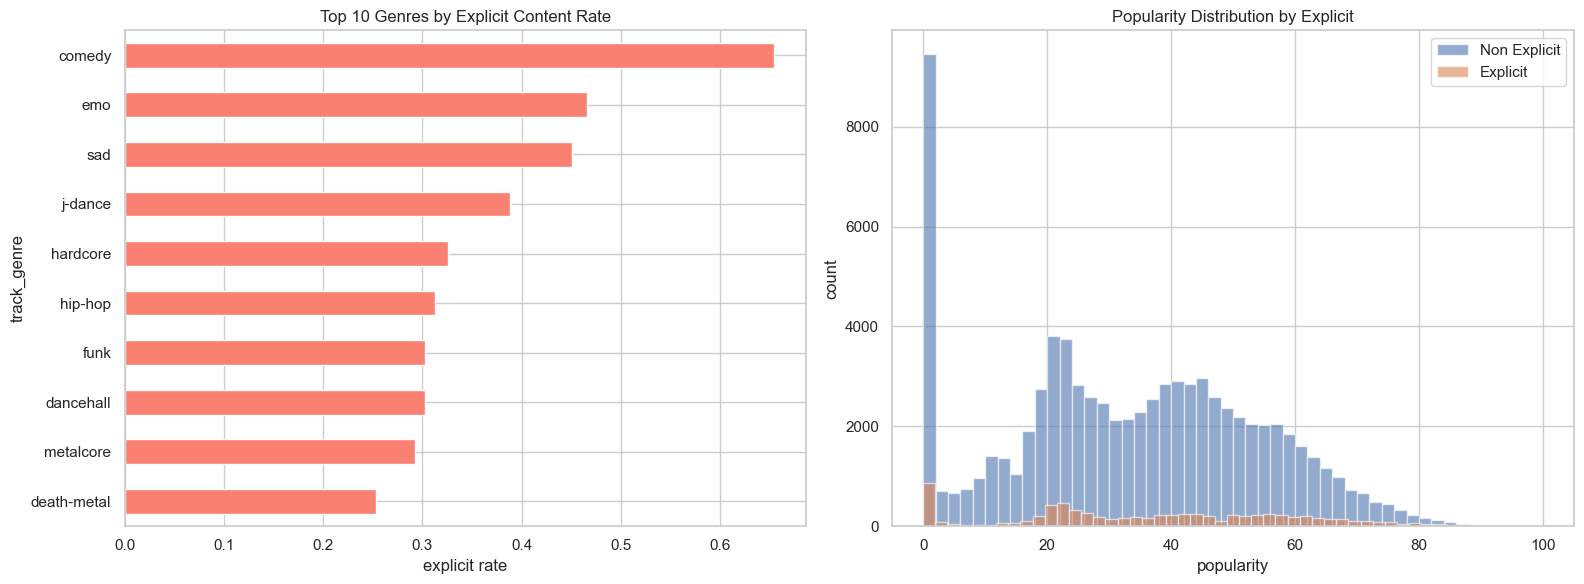

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# explicit by genre top 10
explicit_by_genre = df_exploded.groupby('track_genre')['explicit'].mean().sort_values(ascending=False).head(10)
explicit_by_genre.plot(kind='barh', ax=axes[0], color='salmon')
axes[0].set_title('Top 10 Genres by Explicit Content Rate')
axes[0].set_xlabel('explicit rate')
axes[0].invert_yaxis()

# explicit vs popularity
df.groupby('explicit')['popularity'].plot(kind='hist', ax=axes[1], 
            bins=50, alpha=0.6, legend=True)
axes[1].set_title('Popularity Distribution by Explicit')
axes[1].set_xlabel('popularity')
axes[1].set_ylabel('count')
axes[1].legend(['Non Explicit', 'Explicit'])

plt.tight_layout()
plt.savefig('../reports/figures/eda/explicit_analysis.png', bbox_inches='tight')
plt.show()

# Section 12 - Feature Relationships

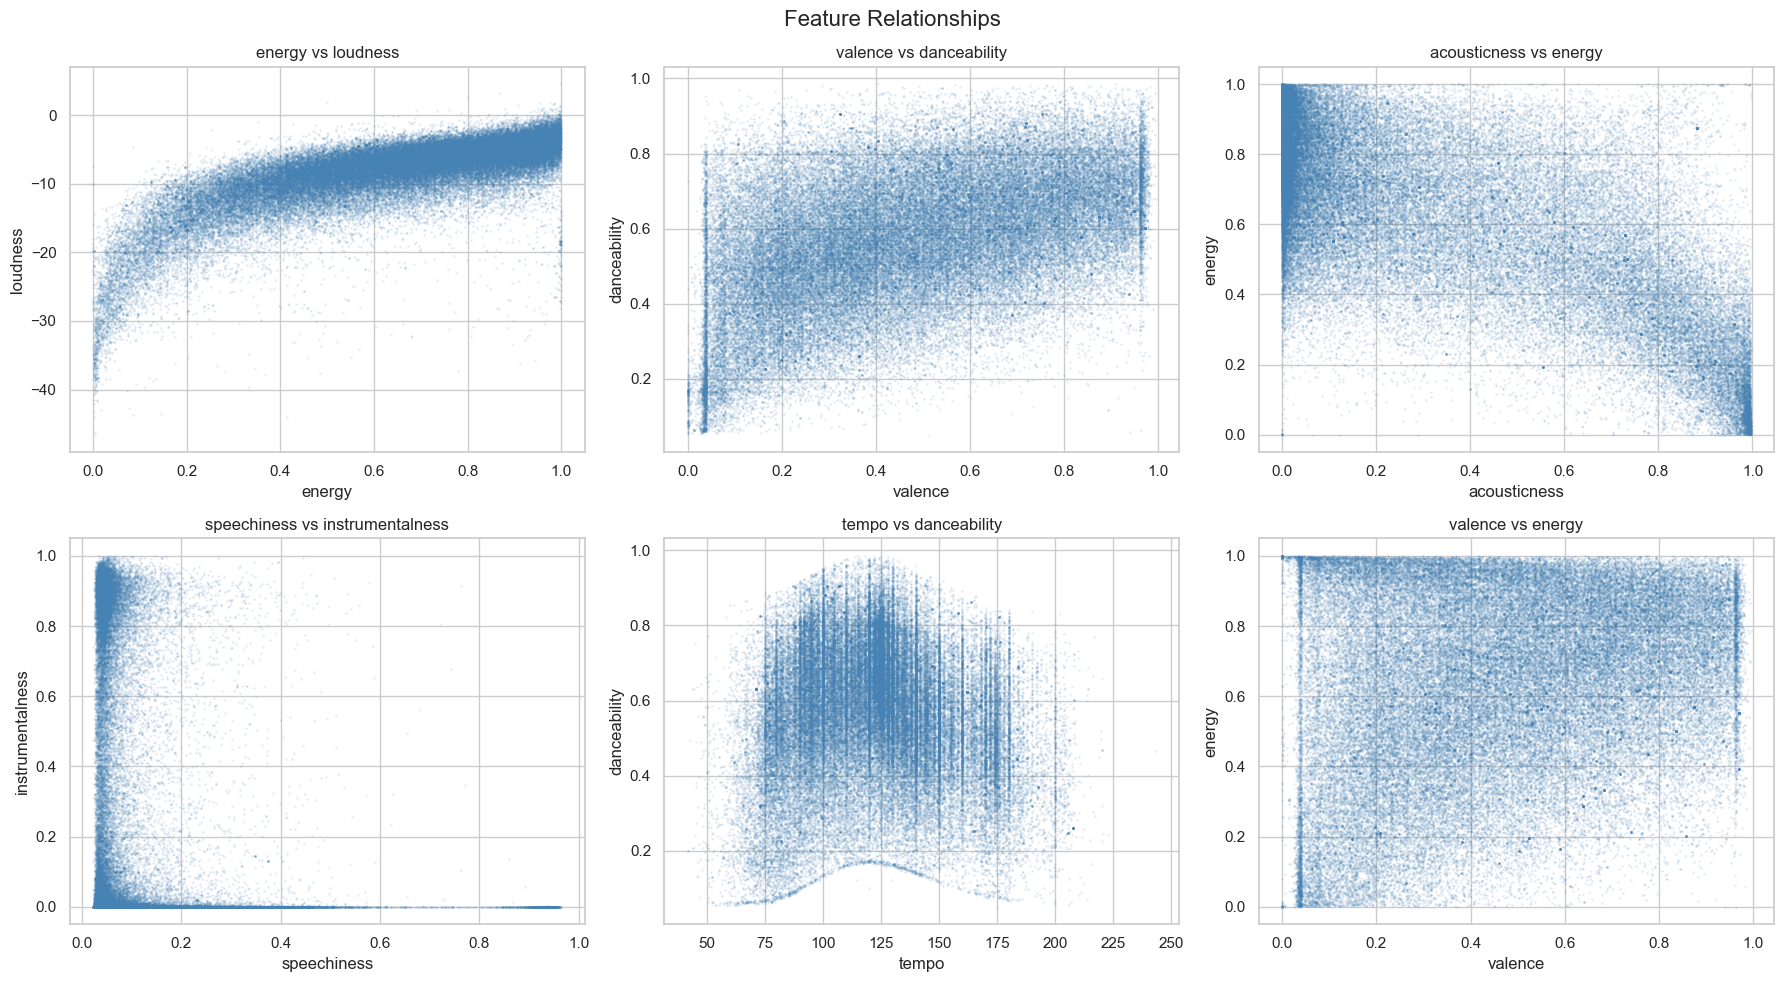

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pairs = [
    ('energy', 'loudness'),
    ('valence', 'danceability'),
    ('acousticness', 'energy'),
    ('speechiness', 'instrumentalness'),
    ('tempo', 'danceability'),
    ('valence', 'energy'),
]

for i, (x, y) in enumerate(pairs):
    axes[i].scatter(df[x], df[y], alpha=0.1, s=1, color='steelblue')
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)
    axes[i].set_title(f'{x} vs {y}')

plt.suptitle('Feature Relationships', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/eda/feature_relationships.png', bbox_inches='tight')
plt.show()

# Section 13 - Multi Genre Analysis

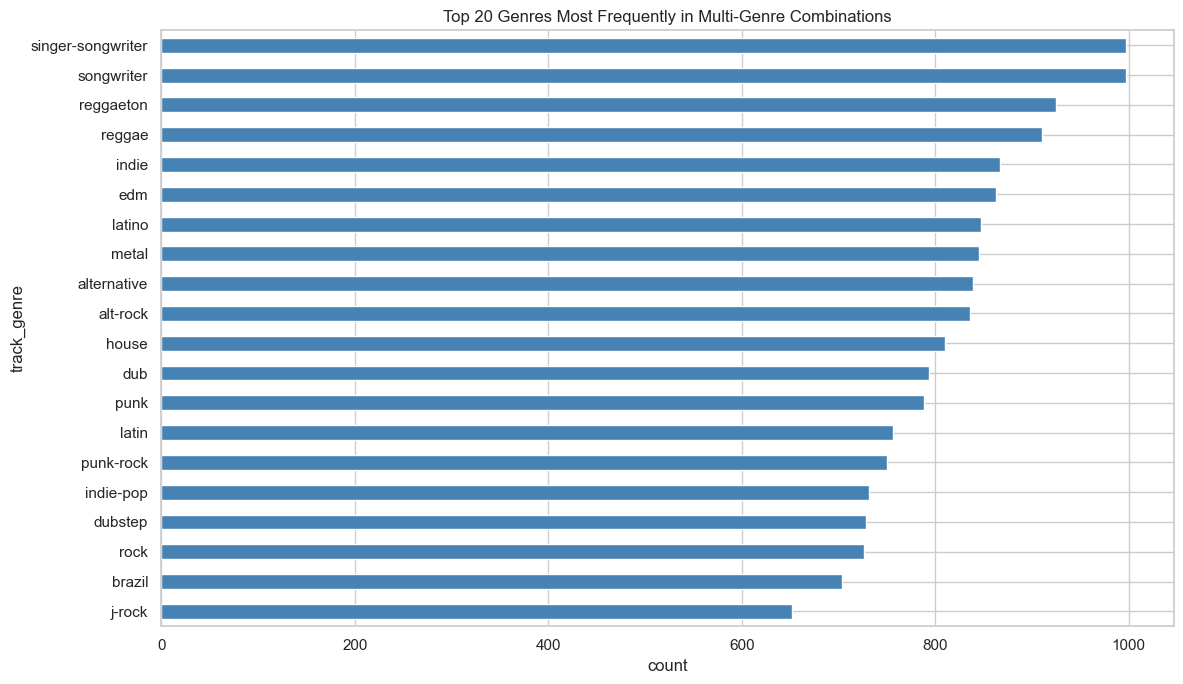

track_genre
singer-songwriter    997
songwriter           997
reggaeton            925
reggae               910
indie                867
edm                  863
latino               847
metal                845
alternative          839
alt-rock             836
house                810
dub                  794
punk                 788
latin                756
punk-rock            750
indie-pop            732
dubstep              728
rock                 726
brazil               704
j-rock               652
Name: count, dtype: int64


In [23]:
# how often each genre appears in multi-genre combinations
multi_genre_df = df[df['track_genre'].str.contains(',')]
multi_genre_exploded = multi_genre_df['track_genre'].str.split(', ').explode()

genre_in_combos = multi_genre_exploded.value_counts().head(20)

plt.figure(figsize=(12, 7))
genre_in_combos.plot(kind='barh', color='steelblue')
plt.title('Top 20 Genres Most Frequently in Multi-Genre Combinations')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/eda/genres_in_combinations.png', bbox_inches='tight')
plt.show()

print(genre_in_combos)

# EDA Summary

In [26]:
print('='*50)
print('EDA SUMMARY')
print('='*50)

print('\n--- Dataset ---')
print(f'Total songs: {df.shape[0]}')
print(f'Total features: {df.shape[1]}')

print('\n--- Popularity Findings ---')
print('1. popularity is weakly correlated with all audio features')
print('2. pop-film and k-pop are most popular genres')
print('3. iranian and romance are least popular genres')
print('4. explicit songs slightly more popular (37 vs 33 avg)')
print('5. major vs minor mode has no effect on popularity')
print('6. musical key has virtually no effect on popularity')
print('7. 4/4 time signature slightly more popular than 3/4 or 5/4')
print('8. sweet spot for popularity is 2-5 minutes duration')
print('9. instrumental songs less popular than vocal songs')
print('10. songs with multiple genres tend to be more popular')

print('\n--- Audio Feature Findings ---')
print('1. energy and loudness strongly correlated (0.76)')
print('2. energy and acousticness strongly inversely correlated (-0.73)')
print('3. danceability and valence moderately correlated (0.48)')
print('4. speechiness and instrumentalness are mutually exclusive')
print('5. most danceable songs peak at 100-130 BPM')
print('6. high energy songs exist at all tempos')

print('\n--- Genre Findings ---')
print('1. each genre has distinct audio fingerprint')
print('2. classical and hip-hop are most distinct genres')
print('3. singer-songwriter and songwriter almost always combined')
print('4. reggaeton, reggae, latino, latin always cluster together')
print('5. comedy has highest explicit rate (65%)')
print('6. electronic genres have longest average duration')

print('\n--- Mood Findings ---')
print('1. happy mood dominates (37.4%)')
print('2. angry second (33.7%)')
print('3. sad third (20.7%)')
print('4. calm least common (8.1%)')

print('\n--- Artist Findings ---')
print('1. Bad Bunny dominates top 20 with 6 songs')
print('2. Bizarrap and Quevedo have highest average popularity')
print('3. most songs != most popular (George Jones 325 songs, not in top popularity)')

print('\n--- Features to Engineer ---')
print('1. mood categories (happy, angry, sad, calm)')
print('2. tempo categories (slow, medium, fast)')
print('3. popularity tiers (emerging, upcoming, mainstream, charttoppers)')
print('4. energy_acousticness ratio')
print('5. dance_energy_score')
print('6. consider dropping key and time_signature (weak effect)')
print('7. consider dropping loudness (correlated with energy)')

EDA SUMMARY

--- Dataset ---
Total songs: 88167
Total features: 20

--- Popularity Findings ---
1. popularity is weakly correlated with all audio features
2. pop-film and k-pop are most popular genres
3. iranian and romance are least popular genres
4. explicit songs slightly more popular (37 vs 33 avg)
5. major vs minor mode has no effect on popularity
6. musical key has virtually no effect on popularity
7. 4/4 time signature slightly more popular than 3/4 or 5/4
8. sweet spot for popularity is 2-5 minutes duration
9. instrumental songs less popular than vocal songs
10. songs with multiple genres tend to be more popular

--- Audio Feature Findings ---
1. energy and loudness strongly correlated (0.76)
2. energy and acousticness strongly inversely correlated (-0.73)
3. danceability and valence moderately correlated (0.48)
4. speechiness and instrumentalness are mutually exclusive
5. most danceable songs peak at 100-130 BPM
6. high energy songs exist at all tempos

--- Genre Findings ---
